<a href="https://colab.research.google.com/github/oOOo-YKS/EmbededGRE/blob/main/notebooks/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# ==========================================
# Project: EmbededGRE
# Purpose: Vector-based GRE Categorization
# ==========================================

import os
import sys

# 1. Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab. Installing dependencies...")
    # These installations only happen in the cloud to keep your offline environment clean
    !pip install -U sentence-transformers pandas scikit-learn
else:
    print("Running offline. Ensure you have 'sentence-transformers' and 'pandas' installed.")

# 2. Essential Imports
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# 3. Model Initialization
# This will download the model the first time you run it (locally or in Colab)
print("Loading AI Embedding Model (all-MiniLM-L6-v2)...")
model = SentenceTransformer('BAAI/bge-large-en-v1.5')

print("\n--- EmbededGRE Environment Ready ---")

Running in Google Colab. Installing dependencies...
Loading AI Embedding Model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]


--- EmbededGRE Environment Ready ---


In [14]:
# 1. Load your cleaned word list
# Make sure the filename matches what you uploaded!
file_path = '/words_only.csv'

try:
    # We assume no header, so we name the column 'word'
    df = pd.read_csv(file_path, header=None, names=['word'])
    print(f"Successfully loaded {len(df)} words.")
except FileNotFoundError:
    print("❌ Error:  not found. Please upload it to the sidebar.")

# 2. Generate Embeddings (The "Vectorization" step)
print("Generating vectors for words... This may take a moment.")
words = df['word'].astype(str).tolist()
embeddings = model.encode(words, show_progress_bar=True)

# 3. Store vectors back into the dataframe for later use
df['vector'] = list(embeddings)

print("\n--- Vector Space Created ---")
print(f"Each word is now represented by a {embeddings.shape[1]}-dimensional vector.")

Successfully loaded 3041 words.
Generating vectors for words... This may take a moment.


Batches:   0%|          | 0/96 [00:00<?, ?it/s]


--- Vector Space Created ---
Each word is now represented by a 1024-dimensional vector.


In [17]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. Load the specific GRE CSV
file_path = '/L-GRE-再要你命3000.csv'

# Since your file has no headers, we will name the columns ourselves
# We only care about the first 3 columns (indices 0, 1, and 2)
df = pd.read_csv(file_path, header=None, usecols=[0, 1, 2],
                 names=['word', 'chinese_def', 'english_def'])

# 2. Clean the Data
# Drop any rows where the word or English definition is accidentally blank
df = df.dropna(subset=['word', 'english_def']).copy()

# Clean up extra spaces or hidden newlines
df['word'] = df['word'].astype(str).str.strip()
df['english_def'] = df['english_def'].astype(str).str.strip()

print(f"✅ Successfully extracted {len(df)} words and definitions!")
print("\n--- Sample of Extracted Data ---")
print(df[['word', 'english_def']].head())

# 3. Load the Advanced Model
print("\nLoading the advanced semantic model...")
# You can use 'all-MiniLM-L6-v2' or 'BAAI/bge-large-en-v1.5' here
model = SentenceTransformer('BAAI/bge-large-en-v1.5')

# 4. THE BLINDFOLD TECHNIQUE
# We vectorize ONLY the English Definition (Column C)
print("Generating vectors based purely on meaning. This prevents spelling bias...")
embeddings = model.encode(df['english_def'].tolist(), show_progress_bar=True)

# 5. Save the vectors back to our dataframe
df['vector'] = list(embeddings)

print("\n🚀 Extraction and Semantic Vectorization Complete!")

✅ Successfully extracted 3041 words and definitions!

--- Sample of Extracted Data ---
         word                                        english_def
0     abandon              1.freedom from constraint\n2.withdraw
1       abase                                              lower
2       abash                                          embarrass
3       abate  1.reduce degree intensity\n2.reduce amount or ...
4  abbreviate                                            briefer

Loading the advanced semantic model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating vectors based purely on meaning. This prevents spelling bias...


Batches:   0%|          | 0/96 [00:00<?, ?it/s]


🚀 Extraction and Semantic Vectorization Complete!


In [18]:
# 1. Install UMAP (Run this once)
!pip install umap-learn hdbscan

import umap
import hdbscan
import numpy as np

print("Step 1: Shrinking 384 dimensions down to 5 (UMAP)...")
# We reduce dimensions so HDBSCAN can actually 'see' the density
reducer = umap.UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
embeddings_reduced = reducer.fit_transform(list(df['vector']))

print("Step 2: Finding natural groups (HDBSCAN)...")
# Now we run HDBSCAN on the smaller, denser 5D space
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3, metric='euclidean')
df['auto_cluster'] = clusterer.fit_predict(embeddings_reduced)

# 3. See the results
num_discovered = len(set(df['auto_cluster'])) - (1 if -1 in df['auto_cluster'].values else 0)
noise_words = list(df['auto_cluster']).count(-1)

print(f"\n✅ SUCCESS: HDBSCAN discovered {num_discovered} distinct semantic categories!")
print(f"⚠️ Noise: Reduced to {noise_words} uncategorized words.")

Step 1: Shrinking 384 dimensions down to 5 (UMAP)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Step 2: Finding natural groups (HDBSCAN)...

✅ SUCCESS: HDBSCAN discovered 184 distinct semantic categories!
⚠️ Noise: Reduced to 1026 uncategorized words.


In [19]:
print("--- Inspecting the EmbeddedGRE Categories ---")

# Let's look at the first 20 categories
for i in range(20):
    # Find words matching the current cluster number
    cluster_words = df[df['auto_cluster'] == i]['word'].tolist()

    # We only print if the cluster exists (some might be empty depending on the math)
    if len(cluster_words) > 0:
        print(f"\n🏷️ Category {i} (Total Words: {len(cluster_words)})")
        # Print up to the first 10 words to guess the theme
        print(", ".join(cluster_words[:10]))

--- Inspecting the EmbeddedGRE Categories ---

🏷️ Category 0 (Total Words: 25)
aboveboard, absolve, disabuse, disengage, disinfect, disinterested, exculpate, exempt, exonerate, extricate

🏷️ Category 1 (Total Words: 7)
bathetic, demotic, mundane, prevalent, quotidian, stock, analogous

🏷️ Category 2 (Total Words: 8)
allegiance, committed, devoted, devout, disciple, fidelity, renegade, staunch

🏷️ Category 3 (Total Words: 6)
esteem, hallow, homage, obeisance, prestige, venerate

🏷️ Category 4 (Total Words: 7)
compliant, insubordinate, meek, obedient, servile, appurtenance, menial

🏷️ Category 5 (Total Words: 8)
affable, amiable, amicable, amity, camaraderie, conversant, rapport, rapprochement

🏷️ Category 6 (Total Words: 6)
hypnotic, lurk, recumbent, respite, slumber, somnolence

🏷️ Category 7 (Total Words: 16)
adulate, commend, encomium, eulogize, exalt, extol, exult, flatter, hymn, laudatory

🏷️ Category 8 (Total Words: 8)
balm, cosset, dovish, equable, imperturbable, mollify, soothe,

In [20]:
from google.colab import files

# Choose the columns you want to keep
# Adjust column names if yours are different (e.g., 'auto_cluster' vs 'cluster')
export_df = df[['word', 'auto_cluster']]  # add 'category' if you have it

# Save to CSV (no index column)
csv_filename = 'gre_words_categorized.csv'
export_df.to_csv(csv_filename, index=False)

print(f"File saved as {csv_filename}")

# Download it to your local machine
files.download(csv_filename)

File saved as gre_words_categorized.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Generating 2D Visual Map...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Map saved! Download 'GRE_Semantic_Map.png' and upload it to your GitHub README.


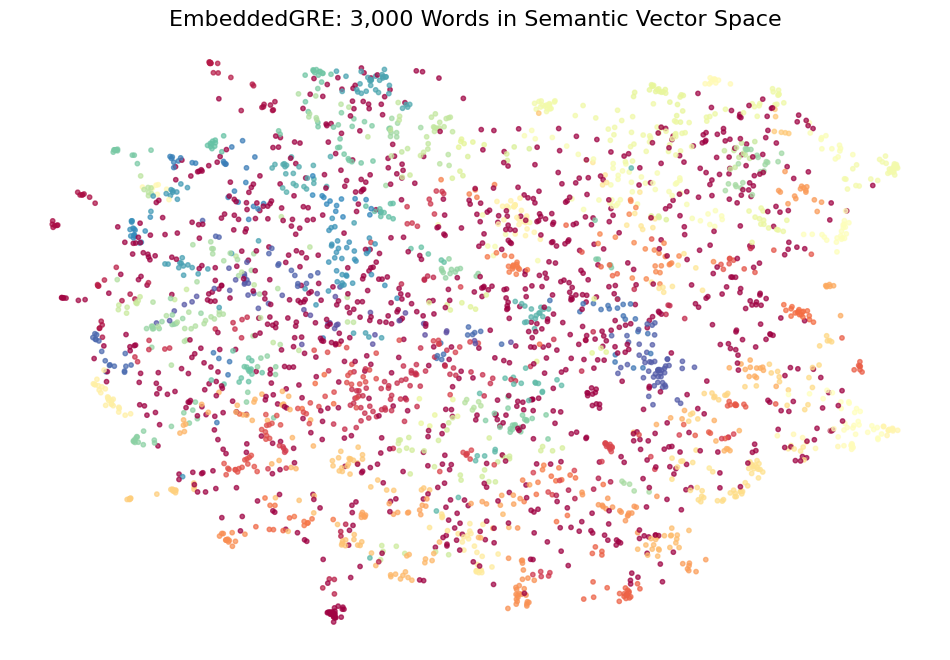

In [21]:
import matplotlib.pyplot as plt
import umap

# 1. Crush vectors to 2D for drawing
print("Generating 2D Visual Map...")
reducer_2d = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer_2d.fit_transform(list(df['vector']))

# 2. Draw the Scatter Plot
plt.figure(figsize=(12, 8))
# Color the dots based on their cluster!
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=df['auto_cluster'], cmap='Spectral', s=10, alpha=0.7)

plt.title("EmbeddedGRE: 3,000 Words in Semantic Vector Space", fontsize=16)
plt.axis('off') # Hides the confusing math axes
plt.savefig('GRE_Semantic_Map.png', dpi=300, bbox_inches='tight')
print("✅ Map saved! Download 'GRE_Semantic_Map.png' and upload it to your GitHub README.")